# Importing Important Modules

In [1]:
import sys
from pathlib import Path

# Add the project root (parent of notebooks) to Python's search path
sys.path.append(str(Path().resolve().parent))

import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from vanilla_bsf import build_model

# Configuration

In [2]:
ACTIVATION_FOLDER = r"C:\Users\97433\BSF_implementation\data\rabit_activations"
INPUT_DIM = 768
NUM_BLOCKS = 4096
BLOCK_SIZE = 4
TOP_K = 16
BATCH_SIZE = 4096
LR = 1e-4
EPOCHS = 300
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Dataset

In [3]:
class PatchDataset(Dataset):

    def __init__(self, folder):

        self.samples = []

        files = sorted(os.listdir(folder))

        for file in tqdm(files):

            if not file.endswith(".npy"):
                continue

            acts = np.load(os.path.join(folder, file))

            # acts = (256,768)

            self.samples.append(acts)

        #####################################
        # Concatenate all patches
        #####################################

        self.samples = np.concatenate(
            self.samples,
            axis=0,
        )

        print(self.samples.shape)

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        x = self.samples[idx]

        return torch.from_numpy(x).float()

# DataLoader

In [4]:
dataset = PatchDataset(ACTIVATION_FOLDER)

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

100%|██████████| 300/300 [00:00<00:00, 586.23it/s]

(76800, 768)


# Model

In [5]:
model = build_model(
    input_dim=INPUT_DIM,
    num_blocks=NUM_BLOCKS,
    block_size=BLOCK_SIZE,
    top_k=TOP_K,
)

model.to(DEVICE)

Vanilla_BSF(
  (W): Linear(in_features=768, out_features=16384, bias=False)
  (D): Linear(in_features=16384, out_features=768, bias=False)
)

# Optimizer

In [6]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
)

criterion = nn.MSELoss()

# Training Loop

In [7]:
# history = []

# best_loss = float("inf")

# for epoch in range(EPOCHS):

#     model.train()

#     running_loss = 0

#     dead_block_counter = None

#     for x in tqdm(train_loader):

#         x = x.to(DEVICE)

#         output = model(x)

#         reconstruction = output["reconstruction"]

#         loss = criterion(
#             reconstruction,
#             x,
#         )

#         optimizer.zero_grad()

#         loss.backward()

#         optimizer.step()

#         running_loss += loss.item()

#         ###################################
#         # Dead blocks
#         ###################################

#         mask = output["active_mask"]

#         if dead_block_counter is None:

#             dead_block_counter = mask.sum(0)

#         else:

#             dead_block_counter += mask.sum(0)

#     epoch_loss = running_loss / len(train_loader)

#     history.append(epoch_loss)

#     dead_blocks = (dead_block_counter == 0).sum().item()

#     print(
#         f"Epoch {epoch+1:03d}"
#         f" | Loss = {epoch_loss:.6f}"
#         f" | Dead Blocks = {dead_blocks}"
#     )

#     if epoch_loss < best_loss:

#         best_loss = epoch_loss

#         torch.save(
#             model.state_dict(),
#             "best_model.pth",
#         )

# Visualization of concepts on rabbit images

In [8]:
inference_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

In [9]:
best_model_path = r"C:\Users\97433\BSF_implementation\own_implementation_vanilla_bsf.pth"

# Load weights
state_dict = torch.load(best_model_path, map_location="cpu")
model.load_state_dict(state_dict)

device = torch.device("cpu")
model.to(device)
model.eval()

C:\Users\97433\AppData\Local\Temp\ipykernel_37336\2524393494.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(best_model_path, map_location="cpu")

Vanilla_BSF(
  (W): Linear(in_features=768, out_features=16384, bias=False)
  (D): Linear(in_features=16384, out_features=768, bias=False)
)

Latent codes: (5120, 4096, 4)
Atoms: (4096, 4, 768)
Images: (20, 224, 224, 3)
Top concepts: [2453 2991]


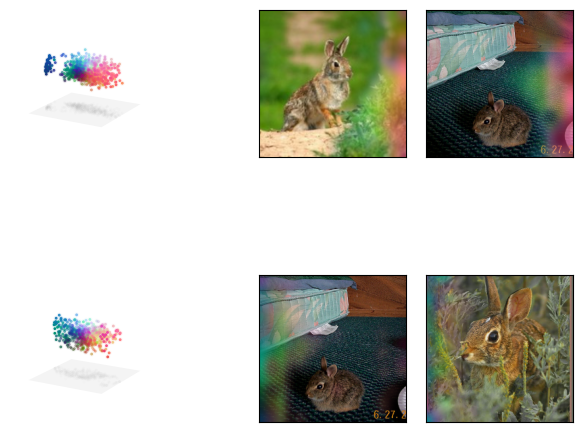

In [14]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from PIL import Image
import matplotlib.pyplot as plt

from viz import plot_concepts

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUM_IMAGES = 20
PATCHES_PER_IMAGE = 256

INPUT_DIM = 768
BLOCK_SIZE = 4
NUM_BLOCKS = 4096
IMAGE_FOLDER = r"C:\Users\97433\BSF_implementation\data\rabit_images"

# ------------------------------------------------------------
# Create dataloader for ONLY the first two images
# ------------------------------------------------------------

subset = Subset(
    dataset,
    range(NUM_IMAGES * PATCHES_PER_IMAGE)
)

loader = DataLoader(
    subset,
    batch_size=256,
    shuffle=False,
    drop_last=False,
)

# ------------------------------------------------------------
# Run BSF
# ------------------------------------------------------------

model.eval()

all_z = []

with torch.no_grad():

    for features in loader:

        features = features.to(device)

        output = model(features)

        # (B,G,b)
        all_z.append(
            output["z_blocks"].cpu()
        )

# (512,4096,4)
z = torch.cat(all_z, dim=0).numpy()

print("Latent codes:", z.shape)

# ------------------------------------------------------------
# Extract decoder atoms
# ------------------------------------------------------------

atoms = (
    model.D.weight.detach()
    .cpu()
    .T
    .reshape(
        NUM_BLOCKS,
        BLOCK_SIZE,
        INPUT_DIM,
    )
    .numpy()
)

print("Atoms:", atoms.shape)

# ------------------------------------------------------------
# Load only first two RGB images
# ------------------------------------------------------------

image_files = sorted(
    [
        f for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]
)

images = []

for file in image_files[:NUM_IMAGES]:

    img = Image.open(
        os.path.join(
            IMAGE_FOLDER,
            file,
        )
    ).convert("RGB")

    images.append(np.asarray(img))

images = np.stack(images)

print("Images:", images.shape)

# ------------------------------------------------------------
# Automatically find the concepts that actually fired
# ------------------------------------------------------------

heat = np.linalg.norm(z, axis=-1)

concept_strength = heat.sum(axis=0)

top_concepts = np.argsort(-concept_strength)[:2]

print("Top concepts:", top_concepts)

# ------------------------------------------------------------
# Visualize
# ------------------------------------------------------------

fig = plot_concepts(
    z=z,
    atoms=atoms,
    images=images,
    concepts=top_concepts,
    grid=16,
    n_img=2,
    ncol_img=2,
)

plt.show()